In [ ]:
# @title
!pip install pandas matplotlib seaborn

In [ ]:
# @title
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("/content/project.csv")
print(df.head())
print(df.describe())
corr = df.corr()

plt.figure()
sns.heatmap(corr, annot=True, cmap='YlGnBu')
plt.title("Correlation Matrix")
plt.show()

plt.figure()
sns.scatterplot(x='study_hours', y='math_score', data=df)
plt.title("Study Hours vs Math Score")
plt.show()

df['average_score'] = df[['math_score','english_score','science_score']].mean(axis=1)
plt.figure()
sns.scatterplot(x='attendance', y='average_score', data=df)
plt.title("Attendance vs Performance")
plt.show()

df[['math_score','english_score','science_score']].hist()
plt.suptitle("Score Distribution")
plt.show()

In [ ]:
# @title
at_risk = df[df['average_score'] < 60]
print("At Risk students:\n", at_risk)

In [ ]:
# @title
sns.regplot(x='study_hours', y='math_score', data=df)

In [6]:
# @title
df.to_csv("processed_students.csv", index=False)

In [ ]:
# @title

import pandas as pd
import numpy as np
import random

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

np.random.seed(42)

students = []

for i in range(1, 201):

    study_hours = round(random.uniform(1, 8), 1)

    attendance = random.randint(50, 100)

    math_score = random.randint(35, 100)

    science_score = random.randint(35, 100)

    english_score = random.randint(35, 100)

    previous_year = random.randint(40, 100)

    final_percentage = round(
        (
            math_score +
            science_score +
            english_score
        ) / 3,
        2
    )


    result = 1 if final_percentage >= 50 else 0

    students.append([
        f"S{i:03}",
        study_hours,
        attendance,
        math_score,
        science_score,
        english_score,
        previous_year,
        final_percentage,
        result
    ])

columns = [
    'Student_ID',
    'Study_Hours',
    'Attendance_Percentage',
    'Math_Score',
    'Science_Score',
    'English_Score',
    'Previous_Year_Score',
    'Final_Percentage',
    'Result'
]

df = pd.DataFrame(students, columns=columns)


df.to_csv("student_performance.csv", index=False)

print("\nDataset Created Successfully!")
print(df.head())

plt.figure(figsize=(10, 6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

plt.figure(figsize=(6, 4))

sns.countplot(
    x='Result',
    data=df,
    palette='Set2'
)

plt.xticks([0, 1], ['FAIL', 'PASS'])

plt.title("Pass / Fail Distribution")

plt.show()

X = df[[
    'Study_Hours',
    'Attendance_Percentage',
    'Math_Score',
    'Science_Score',
    'English_Score',
    'Previous_Year_Score'
]]

y = df['Result']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

# Predictions
lr_pred = lr_model.predict(X_test)


print("\n========== LOGISTIC REGRESSION ==========")

print("\nAccuracy Score:")
print(accuracy_score(y_test, lr_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, lr_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['FAIL', 'PASS'],
    yticklabels=['FAIL', 'PASS']
)

plt.title("Confusion Matrix - Logistic Regression")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# =====================================================
# DECISION TREE MODEL
# =====================================================

dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

# Predictions
dt_pred = dt_model.predict(X_test)

# =====================================================
# DECISION TREE RESULTS
# =====================================================

print("\n========== DECISION TREE ==========")

print("\nAccuracy Score:")
print(accuracy_score(y_test, dt_pred))

print("\nConfusion Matrix:")
dt_cm = confusion_matrix(y_test, dt_pred)
print(dt_cm)

print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

# =====================================================
# FEATURE IMPORTANCE
# =====================================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFEATURE IMPORTANCE")
print(importance)

plt.figure(figsize=(8, 5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance,
    palette='viridis'
)

plt.title("Feature Importance")

plt.show()

sample = [[5, 85, 75, 80, 78, 70]]

prediction = lr_model.predict(sample)

print("\n========== SAMPLE PREDICTION ==========")

if prediction[0] == 1:
    print("Prediction: PASS")
else:
    print("Prediction: FAIL")

df.to_excel("student_performance.xlsx", index=False)

print("\nExcel File Saved Successfully!")

In [ ]:
# @title
!pip install pandas matplotlib seaborn

In [ ]:
# @title
import pandas as pd
import numpy as np
import seaborn as sns

In [ ]:
# @title
df=pd.read_csv("/content/student_performance.csv")
df.head()
print(df.describe())
corr=df.drop('Student_ID', axis=1).corr()

In [ ]:
# @title
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='YlGnBu')
plt.title("Correlation Matrix")
plt.show()
plt.figure()
sns.scatterplot(x='Study_Hours', y='Math_Score', data=df)
plt.title("Study Hours vs Math Score")
plt.show()

In [ ]:
# @title

df['average_score'] = df[['Math_Score','English_Score','Science_Score']].mean(axis=1)
plt.figure()
sns.scatterplot(x='Attendance_Percentage', y='average_score', data=df)
plt.title("Attendance vs Performance")
plt.show()

In [ ]:
# @title
df[['Math_Score','English_Score','Science_Score']].hist(figsize=(10,5))
plt.title("Score Distribution")
plt.show()

In [ ]:
# @title
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("/content/Student.csv")
print(df.head())
print(df.describe())


#corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='YlGnBu')
plt.title("Correlation Matrix")
plt.show()

plt.figure()
sns.scatterplot(x='Study_Hours_per_Day', y='Maths', data=df)
plt.title("Study Hours vs Math Score")
plt.show()


df['average_score'] = df[['Maths','English','Science']].mean(axis=1)
plt.figure()
sns.scatterplot(x='Attendance_percentage', y='average_score', data=df)
plt.title("Attendance vs Performance")
plt.show()

df[['Maths','English','Science']].hist(figsize=(10,5))
plt.suptitle("Score Distribution")
plt.show()

Project

In [15]:
!pip install pandas matplotlib seaborn

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("/content/Student.csv")
df.head()

,Reg_No,Attendance_percentage,Study_Hours_per_Day,English,Maths,Science,Kannada
0,10,90,5,98,95,99,100
1,11,80,4,89,80,79,88
2,12,30,1,45,34,23,44
3,13,40,3,67,76,75,77
4,14,50,2,55,58,60,59


In [18]:
print(df.head())
print(df.describe())

   Reg_No  Attendance_percentage  Study_Hours_per_Day  English  Maths  \
0      10                     90                    5       98     95   
1      11                     80                    4       89     80   
2      12                     30                    1       45     34   
3      13                     40                    3       67     76   
4      14                     50                    2       55     58   

   Science  Kannada  
0       99      100  
1       79       88  
2       23       44  
3       75       77  
4       60       59  
          Reg_No  Attendance_percentage  Study_Hours_per_Day  English  \
count   6.000000               6.000000             6.000000   6.0000   
mean   12.500000              51.666667             2.500000  61.0000   
std     1.870829              27.868740             1.870829  31.2474   
min    10.000000              20.000000             0.000000  12.0000   
25%    11.250000              32.500000             1.250000  47

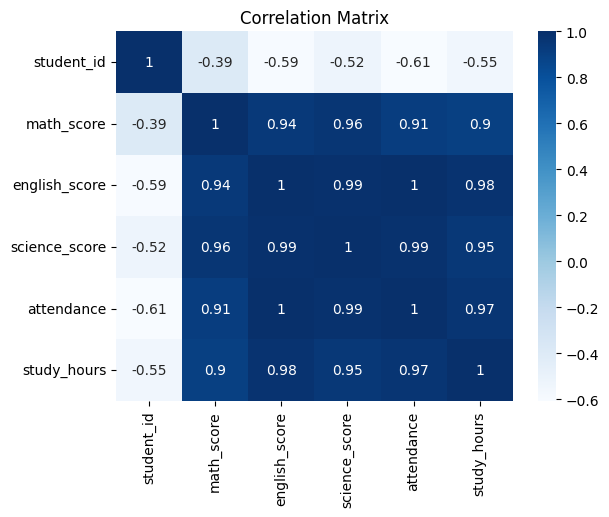

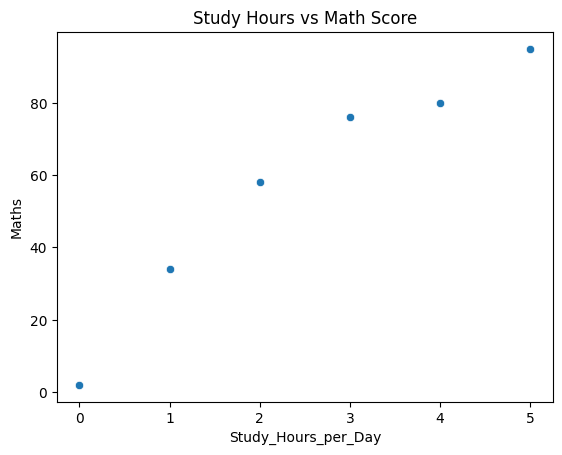

In [19]:
#plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title("Correlation Matrix")
plt.show()
plt.figure()
sns.scatterplot(x='Study_Hours_per_Day', y='Maths', data=df)
plt.title("Study Hours vs Math Score")
plt.show()

0    97.333333
1    82.666667
2    34.000000
3    72.666667
4    57.666667
5     8.333333
Name: average_score, dtype: float64


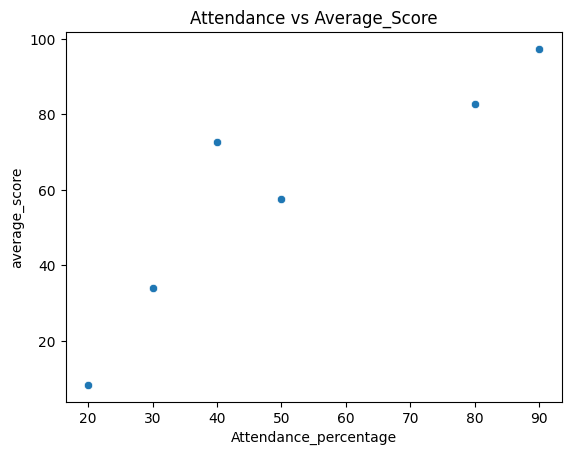

In [20]:
plt.figure()
df['average_score'] = df[['Maths','English','Science']].mean(axis=1)
print(df.average_score)
sns.scatterplot(x='Attendance_percentage', y='average_score', data=df)
plt.title("Attendance vs Average_Score")
plt.show()

In [21]:
df['average_score'] = df[['Maths','English','Science']].mean(axis=1)
print(df.average_score)

0    97.333333
1    82.666667
2    34.000000
3    72.666667
4    57.666667
5     8.333333
Name: average_score, dtype: float64


In [22]:
df['At_Risk'] = (
    (df['Attendance_percentage'] < 40) |
    (df['Study_Hours_per_Day'] < 1) |
    (df['average_score'] < 50)
)

In [23]:
at_risk_students = df[df['At_Risk'] == True]

print(at_risk_students)

   Reg_No  Attendance_percentage  Study_Hours_per_Day  English  Maths  \
2      12                     30                    1       45     34   
5      15                     20                    0       12      2   

   Science  Kannada  average_score  At_Risk  
2       23       44      34.000000     True  
5       11        5       8.333333     True  


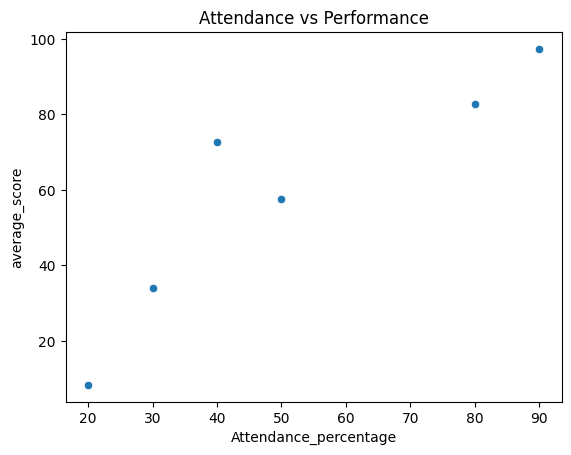

In [24]:
plt.figure()
sns.scatterplot(x='Attendance_percentage', y='average_score', data=df)
plt.title("Attendance vs Performance")
plt.show()

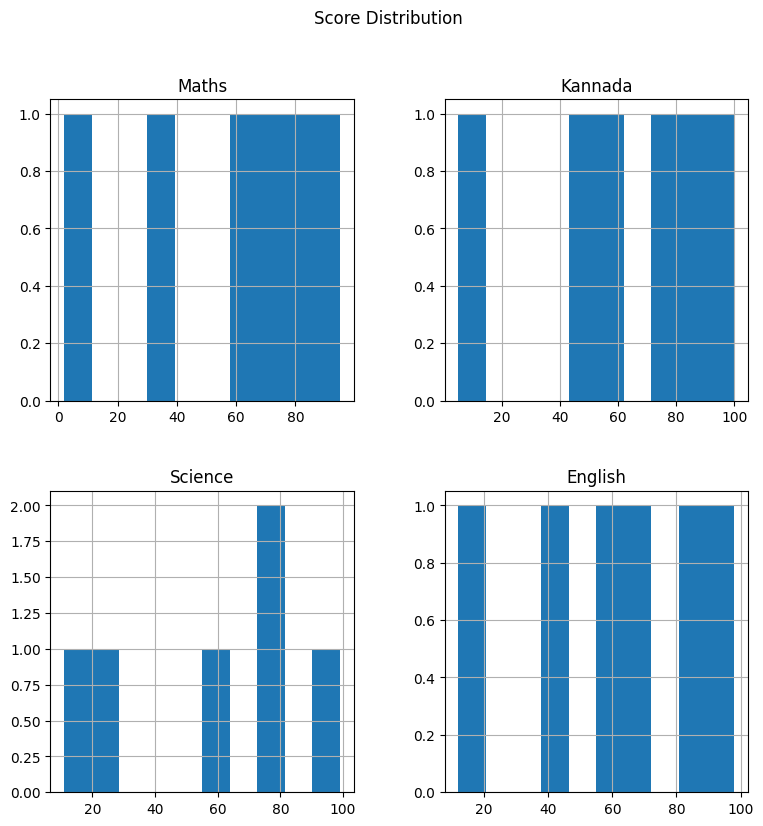

In [48]:
df[['Maths','Kannada','Science','English']].hist(figsize=(9,9))
plt.suptitle("Score Distribution")
plt.show()

array([[<Axes: title={'center': 'Maths'}>,
        <Axes: title={'center': 'English'}>],
       [<Axes: title={'center': 'Science'}>,
        <Axes: title={'center': 'Kannada'}>]], dtype=object)

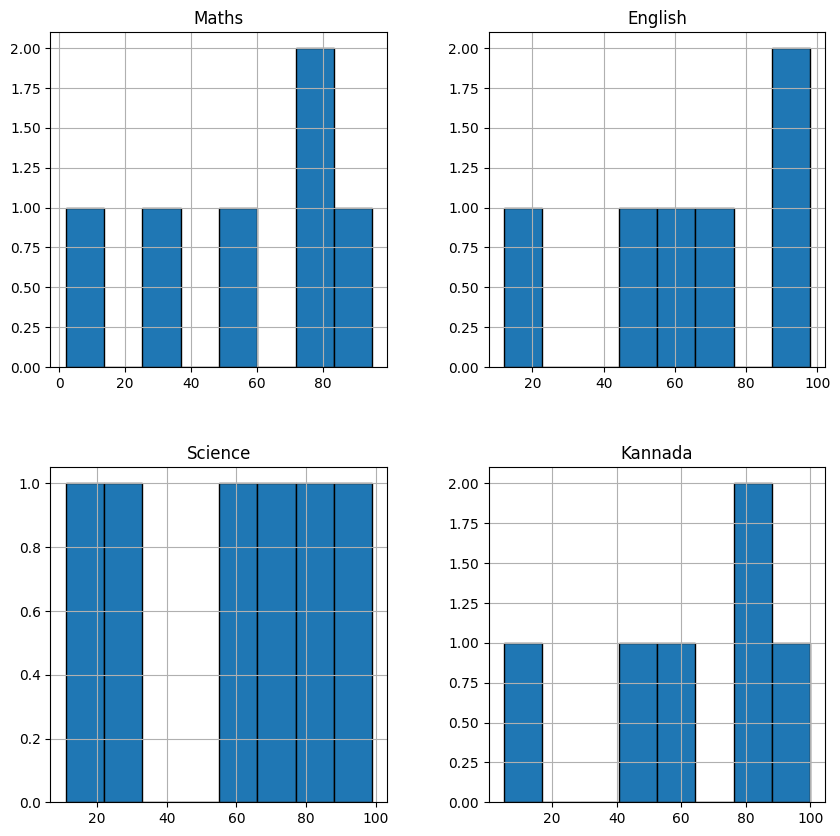

In [50]:
df[['Maths','English','Science','Kannada']].hist(
    bins=8,
    figsize=(10,10),
    edgecolor='black'
)